# 一、前言

Torch-5 和 Torch-6 是同一个模型、同一套数学，只是把"手搓零件"换成 PyTorch 现成的高级 API。 会看到两个"魔法时刻"：网络只要 5 行、梯度自动化简成 p − y。

# 二、程序

## 1.数据（复用，只做一次）

In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms, datasets
from torch.utils import data

trans = transforms.ToTensor()
mnist_train = datasets.FashionMNIST(root='../data', train=True, transform=trans, download=True)
mnist_test  = datasets.FashionMNIST(root='../data', train=False, transform=trans, download=True)
batch_size = 256
train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True)
test_iter  = data.DataLoader(mnist_test, batch_size, shuffle=False)

## 2.定义网络：（重点）

In [2]:
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))
'''
1.nn.Flatten() —— 自动拉平
等价于 Torch-5 的手写 X.reshape((-1, 784))；
进来的 [256, 1, 28, 28] 自动变成 [256, 784]，不需要你算 -1。

2.nn.Linear(784, 10) —— 自动建 W 和 b
等价于 Torch-5 手动建的 W（784×10）和 b（10），并且自动初始化（默认随机，不用 torch.normal）；
注意一个形状差异：nn.Linear 内部存的权重形状是 [10, 784]，和手写版的 [784, 10] 是转置关系——因为 PyTorch 约定 out = X @ W.T + b。方向不同，数学等价；
可以这样验证：net[1].weight.shape → [10, 784]，net[1].bias.shape → [10]。

3.nn.Sequential —— 把两层串成流水线
输入先进 Flatten，再进 Linear，输出直接就是 10 个 logits。

注意！net 输出的是 logits（原始分数），不是概率。因为 softmax 被挪到损失函数里去了（下面讲为什么）
这是最容易踩的坑：有人习惯性地在 Linear 后面又套一层 softmax，结果双重 softmax，训练直接崩。记住：net 只输出 logits。
'''

'\n1.nn.Flatten() —— 自动拉平\n等价于 Torch-5 的手写 X.reshape((-1, 784))；\n进来的 [256, 1, 28, 28] 自动变成 [256, 784]，不需要你算 -1。\n\n2.nn.Linear(784, 10) —— 自动建 W 和 b\n等价于 Torch-5 手动建的 W（784×10）和 b（10），并且自动初始化（默认随机，不用 torch.normal）；\n注意一个形状差异：nn.Linear 内部存的权重形状是 [10, 784]，和手写版的 [784, 10] 是转置关系——因为 PyTorch 约定 out = X @ W.T + b。方向不同，数学等价；\n可以这样验证：net[1].weight.shape → [10, 784]，net[1].bias.shape → [10]。\n\n3.nn.Sequential —— 把两层串成流水线\n输入先进 Flatten，再进 Linear，输出直接就是 10 个 logits。\n\n注意！net 输出的是 logits（原始分数），不是概率。因为 softmax 被挪到损失函数里去了（下面讲为什么）\n这是最容易踩的坑：有人习惯性地在 Linear 后面又套一层 softmax，结果双重 softmax，训练直接崩。记住：net 只输出 logits。\n'

## 3.初始化（可选项，但保持一致）

In [3]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std = 0.01)
net.apply(init_weights)
'''
nn.Linear 默认会自己初始化，但为了和 3.6 对齐（标准正态 × 0.01），所以手动覆盖
net.apply(...)：把函数逐个应用到网络里每一个模块上，碰到 Linear 就初始化它的权重；
不做这步也能跑，因为默认初始化本来就合理。做了更严谨。
'''

'\nnn.Linear 默认会自己初始化，但为了和 3.6 对齐（标准正态 × 0.01），所以手动覆盖\nnet.apply(...)：把函数逐个应用到网络里每一个模块上，碰到 Linear 就初始化它的权重；\n不做这步也能跑，因为默认初始化本来就合理。做了更严谨。\n'

## 4.损失:nn.CrossEntropyLoss（第一个魔法时刻）

In [4]:
loss = nn.CrossEntropyLoss(reduction='none')

这个函数 Torch 的 softmax + cross_entropy 合并成一步，还额外做了数值稳定处理。 这是本节最核心的概念。<br>
为什么必须合并？—— 数值灾难问题<br>
回想 Torch-5 ：softmax 先算 e^z，交叉熵再算 −log(p)。合起来看：<br>
$-\log\!\Big(\frac{e^{z_y}}{\sum_j e^{z_j}}\Big) = -\big(z_y - \log\sum_j e^{z_j}\big) = \log\sum_j e^{z_j} - z_y$<br>

右边的式子叫 log-sum-exp。数学上它和左边完全相等，但计算上天差地别：<br>
左边：先算 e^z。万一某个 logit 是 1000，e^1000 直接溢出成 inf，后面全废；<br>
右边：从头到尾不出现 e^z，只用 log 和加减法，稳如泰山。<br>

nn.CrossEntropyLoss 内部就是用右边这种稳定形式一步算完，既不单独算 softmax 的 exp，也不单独算 log。<br>
所以结论就一句话：softmax 被"藏"进损失里了，你的网络只负责吐 logits。<br>

梯度化简（第二个魔法时刻）<br>
因为 softmax 和交叉熵在同一个函数里合并求导，链条一展开，梯度变成惊人的简洁形式：<br>
$\frac{\partial L}{\partial z_i} = p_i - y_i \quad\text{（}y_i\text{ 是 one-hot 真实标签）}$<br>
简单地说：某个类别的梯度 = 模型给它的概率 − 它是不是真实类别。<br>

拿靴子例子验证一下直觉：<br>
模型预测：靴子 p₉=0.59，凉鞋 p₅=0.22；真实标签：靴子（one-hot 里 y₉=1）；<br>
靴子的梯度：0.59 − 1 = −0.41 → 负数 → 梯度下降把 z₉ 往上推（负梯度方向）→ 靴子的分数被抬高；<br>
凉鞋的梯度：0.22 − 0 = 0.22 → 正数 → 把 z₅ 往下压 → 凉鞋的分数被压低；<br>
其他的：p_i − 0 = p_i，全都 > 0，全被往下压。

"推真实类别上去、把其他 9 个压下去"，和讲交叉熵时那句话一模一样，现在它精确地变成了梯度公式。这就是 Softmax+交叉熵"天生一对"的完整兑现。

## 5.优化器：torch.optim.SGD

In [5]:
trainer = torch.optim.SGD(net.parameters(), lr = 0.1)
'''
net.parameters()：自动收集网络里所有可训练参数（就是 Linear 的 weight 和 bias）；
之后 trainer.step() = 手写版里"param -= lr * grad / batch_size"那一整段。
'''

'\nnet.parameters()：自动收集网络里所有可训练参数（就是 Linear 的 weight 和 bias）；\n之后 trainer.step() = 手写版里"param -= lr * grad / batch_size"那一整段。\n'

## 6.准确率

In [6]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis = 1)      # 每行取概率最大的列号 = 预测类别
    cmp = (y_hat.type(y.dtype) == y)       # 逐元素比较，True/False
    return float(cmp.type(y.dtype).sum())  # 统计预测对的个数

def evaluate_accuracy(net, data_iter):
    acc_sum, n = 0.0, 0
    for X, y in data_iter:
        acc_sum += accuracy(net(X),y)     # 每个批次猜对的个数
        n += y.numel()                     # 累计总样本数
    return acc_sum / n                     # 猜对个数 ÷ 总数
'''
y_hat.argmax(axis=1)：沿第 1 维（每行）找最大值的下标——即"模型最相信的类别编号"。argmax 是分类预测的核心动作；
y_hat.type(y.dtype)：把预测转成和 y 一样的整数类型，才能比较（概率是 float，标签是 int64）；
cmp.type(y.dtype).sum()：True/False 转成 1/0 再求和 = 猜对的个数；
y.numel()：元素个数，这里就是 batch 大小；返回张量里面所有元素的总个数（number‑of‑elements），不管几维，把全部元素数量算出来。
最后 acc_sum / n = 准确率。

accuracy(y_hat, y) —— 一个 batch 的"计数器"
输入：一批预测结果 + 一批真实标签；
干的事：argmax 取预测类别 → 和真实标签逐元素比较 → 数出这一批猜对几个；
返回：一个整数（猜对的个数）。它不自己循环，是纯工具函数。

evaluate_accuracy(net, data_iter) —— 整个数据集的"准确率计算器"
干的事：自己开循环，把数据集所有 batch 喂给 net，把每个 batch 的"猜对个数"累加，再除以总样本数；
返回：一个 0~1 的比率（准确率）。
'''

'\ny_hat.argmax(axis=1)：沿第 1 维（每行）找最大值的下标——即"模型最相信的类别编号"。argmax 是分类预测的核心动作；\ny_hat.type(y.dtype)：把预测转成和 y 一样的整数类型，才能比较（概率是 float，标签是 int64）；\ncmp.type(y.dtype).sum()：True/False 转成 1/0 再求和 = 猜对的个数；\ny.numel()：元素个数，这里就是 batch 大小；返回张量里面所有元素的总个数（number‑of‑elements），不管几维，把全部元素数量算出来。\n最后 acc_sum / n = 准确率。\n\naccuracy(y_hat, y) —— 一个 batch 的"计数器"\n输入：一批预测结果 + 一批真实标签；\n干的事：argmax 取预测类别 → 和真实标签逐元素比较 → 数出这一批猜对几个；\n返回：一个整数（猜对的个数）。它不自己循环，是纯工具函数。\n\nevaluate_accuracy(net, data_iter) —— 整个数据集的"准确率计算器"\n干的事：自己开循环，把数据集所有 batch 喂给 net，把每个 batch 的"猜对个数"累加，再除以总样本数；\n返回：一个 0~1 的比率（准确率）。\n'

## 7.训练循环：和 Torch-5 只差三行

In [7]:
loss = nn.CrossEntropyLoss(reduction='none')

num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc, n = 0.0, 0.0, 0
    for X, y in train_iter:
        trainer.zero_grad()          # 清空上一步的梯度
        y_hat = net(X)               # 前向：输出 logits
        l = loss(y_hat, y)          #  一步完成 softmax+交叉熵,[256]
        l.mean().backward()       # 反向传播,更新：用均值梯度（关键！）, 这儿原本是 l.sum(),出现了 loss 被放大的爆炸
        trainer.step()               # 更新参数
        train_loss += l.sum().item()  # 打印：用 sum 累加
        train_acc += accuracy(y_hat, y)
        n += y.numel()                 # 分母：样本数
    test_acc = evaluate_accuracy(net, test_iter)
    print(f'epoch{epoch + 1}, loss {train_loss / n:.3f} '
          f'train acc{train_acc / n:.3f}, test acc{test_acc:.3f}')
'''
对照 Torch-5 手写版，只换了三行：
sgd([W, b], lr, batch_size) → trainer.step()；
param.grad.zero_()（在 sgd 里）→ trainer.zero_grad()（循环开头，更符合惯例）；
其他全部一样，accuracy 和 evaluate_accuracy 直接复用 Torch-5 的。
有个细节值得注意：y_hat 现在是 logits 而不是概率，但 accuracy(y_hat, y) 里的 argmax 照样算得对——为什么？
因为 softmax 是保序的！argmax(logits) = argmax(softmax(logits))，最大分数和最大概率指向同一个类别。上一节学的"保序"在这里悄悄派上了用场。
'''

/home/wsl2/anaconda3/envs/als/lib/python3.10/site-packages/torch/autograd/graph.py:979: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


epoch1, loss 0.787 train acc0.748, test acc0.792
epoch2, loss 0.571 train acc0.813, test acc0.806
epoch3, loss 0.525 train acc0.826, test acc0.816
epoch4, loss 0.501 train acc0.833, test acc0.824
epoch5, loss 0.486 train acc0.836, test acc0.823
epoch6, loss 0.474 train acc0.840, test acc0.828
epoch7, loss 0.465 train acc0.843, test acc0.831
epoch8, loss 0.458 train acc0.845, test acc0.820
epoch9, loss 0.453 train acc0.847, test acc0.833
epoch10, loss 0.448 train acc0.848, test acc0.832


'\n对照 Torch-5 手写版，只换了三行：\nsgd([W, b], lr, batch_size) → trainer.step()；\nparam.grad.zero_()（在 sgd 里）→ trainer.zero_grad()（循环开头，更符合惯例）；\n其他全部一样，accuracy 和 evaluate_accuracy 直接复用 Torch-5 的。\n有个细节值得注意：y_hat 现在是 logits 而不是概率，但 accuracy(y_hat, y) 里的 argmax 照样算得对——为什么？\n因为 softmax 是保序的！argmax(logits) = argmax(softmax(logits))，最大分数和最大概率指向同一个类别。上一节学的"保序"在这里悄悄派上了用场。\n'

## 8.预测

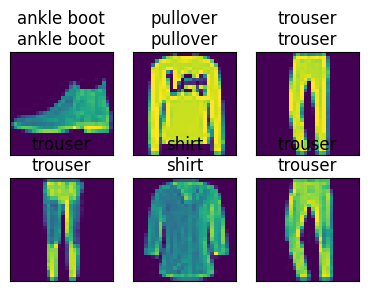

In [8]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    figsize = (num_cols * scale, num_rows * scale)   # (9*1.5, 2*1.5) = (13.5, 3)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()                           # 2维数组拉平成一维
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        ax.imshow(img.numpy())            # 张量要转成numpy才能imshow
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    plt.show()

def get_fashion_mnist_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]
    
def predict_ch3(net, test_iter, n=6):
    for X, y in test_iter:      # 拿一批测试图
        break
    trues = get_fashion_mnist_labels(y)                     # 真实标签
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1)) # 预测标签
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    # 上面：每张图标题 = "真实标签" 换行 "预测标签"，上下对照
    show_images(X[0:n].reshape((n, 28, 28)), 2, n // 2, titles=titles[0:n])
predict_ch3(net, test_iter)   # 复用 3.6 的函数，net 内部自动吐 logits

# 三、小结

1. nn.Linear(784, 10) 的 weight 形状是什么？为什么和手写版 W 相反？<br>
新的 weight 形状是（10，784）,因为 pytorch 内部对这个 W 有转置性质，所以反着写
   
2. 为什么 net 输出 logits 而不是概率？如果把 softmax 也塞进 net，会发生什么？<br>
net 现在的功能就只有两个，一个是给 X 的样本进行压缩降维，另一个功能是构建 W 和 b 的形状；如果将 softmax 也塞进 net 那么就可能会造成数值爆炸，因为 Loss 里有softmax
 
3. nn.CrossEntropyLoss 为什么要把 softmax 藏进内部？避免什么数值灾难？<br>
可以将 softmax 和 交叉熵相结合减少运算量，如果两个板块分开的话，那么有可能在指数化的时候就超出运算了，而在两者相结合后这个危险就被避免了，因为指数化那一步其实被和谐掉了，且最终的效果和手写版是一样的
 
4. 用靴子例子：真实类别是 9，模型给出 p₉=0.59、p₅=0.22，那 z₉ 和 z₅ 的梯度各是多少？符号说明什么？<br>
Z9 = 0.59 -1 = -0.41 ; Z5 = 0.22 - 0 0.22 ; 梯度下降的更新公式：<br>
$\text{z} \leftarrow \text{z} - \text{lr} \times \text{梯度}$<br>
梯度是负的，− lr × 负数 = 加上一个数 → z 变大；梯度是正的，− lr × 正数 = 减去一个数 → z 变小。
 
5. trainer.zero_grad() 和 trainer.step() 分别对应手写版里的什么动作？<br>
param.grad.zero_() 和 sgd([W, b], lr, batch_size) 
 
6. logits 输入到 accuracy 为什么还能正确 argmax？<br>
因为 logits 和 概率都是保序性的，argmax 始终寻找的都是最大值，所以效果还是一样的


# 四、Bug

梯度用了 l.sum() 而非 l.mean()（学习率被放大 256 倍）<br>
症状：loss 偏大 ~80 倍（36 vs 0.45）；train acc 卡在 0.80；test acc 却正常（0.83）。<br>
根因：reduction='none' 时 l 是 [256]。<br>
l.sum().backward() → 对"256 个损失的和"求梯度 ≈ 256 × 平均梯度；<br>
trainer.step()（SGD）不做 batch 归一化 → 直接 θ ← θ − lr·梯度；<br>
净效果：有效学习率 = 0.1 × 256 = 25.6，被放大 256 倍。

为什么手写版（Torch-5）用 l.sum() 却没事？<br>
3.6 的 sgd() 内部写了 param.grad / batch_size，把和归一回了平均；<br>
3.7 的 trainer.step() 不除 → 3.6 的写法 + 3.7 的优化器 = 错位组合。<br>
修复：l.sum().backward() → l.mean().backward()。